**MERUBAH FORMAT DATASET AGAR LEBIH MUDAH DIBACA PROGRAM**

In [2]:
import pandas as pd

# 1. Membaca dataset CSV dari folder 'dataset'
df = pd.read_csv('dataset/data_tugas_asa.csv')

# 2. Mengubah DataFrame menjadi list of dictionaries agar lebih luwes 
# saat dimasukkan ke dalam parameter fungsi Brute Force, DP, dan Tabu Search
daftar_tugas = df.to_dict('records')

# Menampilkan 3 data pertama untuk memastikan struktur data sudah benar
print("Format data siap proses:")
for tugas in daftar_tugas[:3]:
    print(tugas)

Format data siap proses:
{'ID_Tugas': 'T1', 'Nama_Tugas': 'Proyek Makalah ASA', 'Durasi_Pengerjaan_Jam': 8, 'Deadline_Jam': 48, 'Bobot_Nilai': 30}
{'ID_Tugas': 'T2', 'Nama_Tugas': 'Praktikum Jarkom', 'Durasi_Pengerjaan_Jam': 3, 'Deadline_Jam': 24, 'Bobot_Nilai': 10}
{'ID_Tugas': 'T3', 'Nama_Tugas': 'Tugas Besar PBO', 'Durasi_Pengerjaan_Jam': 10, 'Deadline_Jam': 72, 'Bobot_Nilai': 40}


**ALGORITMA BRUTE FORCE**

In [ ]:
def jalankan_eksperimen_bf(dataset_lengkap):
    print("="*115)
    print(f"{'N':<5} | {'Status':<10} | {'Profit Max':<10} | {'Waktu (Detik)':<15} | {'Urutan Terbaik [ID: Durasi, Bobot]'}")
    print("="*115)
    
    for n in range(3, 16):
        subset_tugas = dataset_lengkap[:n]
        
        mulai = time.perf_counter()
        bobot, urutan, is_timeout = brute_force_sequencing_with_timeout(subset_tugas, 2)
        selesai = time.perf_counter()
        
        durasi = selesai - mulai
        
        if is_timeout:
            status_str = "TIMEOUT"
            bobot_str = "N/A"
            waktu_str = f"> {durasi:.6f}"
            urutan_str = "N/A"
        else:
            status_str = "BERHASIL"
            bobot_str = str(bobot)
            waktu_str = f"{durasi:.6f}"
            
            urutan_ekstrak = [f"[{t['ID_Tugas']}: {t['Durasi_Pengerjaan_Jam']}j, {t['Bobot_Nilai']}]" for t in urutan]
            urutan_str = " -> ".join(urutan_ekstrak)
            
        print(f"{n:<5} | {status_str:<10} | {bobot_str:<10} | {waktu_str:<15} | {urutan_str}")

jalankan_eksperimen_bf(daftar_tugas)

N     | Status     | Profit Max | Waktu (Detik)   | Urutan Terbaik [ID: Durasi, Bobot]
3     | BERHASIL   | 80         | 0.000031        | [T1: 8j, 30] -> [T2: 3j, 10] -> [T3: 10j, 40]
4     | BERHASIL   | 95         | 0.000053        | [T1: 8j, 30] -> [T2: 3j, 10] -> [T3: 10j, 40] -> [T4: 4j, 15]
5     | BERHASIL   | 105        | 0.000336        | [T1: 8j, 30] -> [T2: 3j, 10] -> [T3: 10j, 40] -> [T5: 2j, 10] -> [T4: 4j, 15]
6     | BERHASIL   | 125        | 0.001730        | [T1: 8j, 30] -> [T5: 2j, 10] -> [T6: 2j, 20] -> [T2: 3j, 10] -> [T3: 10j, 40] -> [T4: 4j, 15]
7     | BERHASIL   | 150        | 0.015808        | [T1: 8j, 30] -> [T5: 2j, 10] -> [T6: 2j, 20] -> [T2: 3j, 10] -> [T3: 10j, 40] -> [T4: 4j, 15] -> [T7: 5j, 25]
8     | BERHASIL   | 160        | 0.126778        | [T1: 8j, 30] -> [T5: 2j, 10] -> [T6: 2j, 20] -> [T2: 3j, 10] -> [T3: 10j, 40] -> [T4: 4j, 15] -> [T7: 5j, 25] -> [T8: 3j, 10]
9     | BERHASIL   | 175        | 1.320452        | [T1: 8j, 30] -> [T5: 2j, 10] -> [

**ALGORITMA DYNAMIC PROGRAMMING**

In [ ]:
import time

def dynamic_programming_sequencing_with_timeout(daftar_tugas, batas_waktu_detik=2):
    tugas_sorted = sorted(daftar_tugas, key=lambda x: x['Deadline_Jam'])
    n = len(tugas_sorted)
    
    if n == 0:
        return 0, [], False

    max_waktu = max(tugas['Deadline_Jam'] for tugas in tugas_sorted)
    
    dp = [[0 for _ in range(max_waktu + 1)] for _ in range(n + 1)]
    keep = [[False for _ in range(max_waktu + 1)] for _ in range(n + 1)]
    
    waktu_mulai_internal = time.time()
    
    for i in range(1, n + 1):
        
        if time.time() - waktu_mulai_internal > batas_waktu_detik:
            return 0, [], True
            
        tugas_saat_ini = tugas_sorted[i-1]
        durasi = tugas_saat_ini['Durasi_Pengerjaan_Jam']
        bobot = tugas_saat_ini['Bobot_Nilai']
        deadline = tugas_saat_ini['Deadline_Jam']
        
        for t in range(1, max_waktu + 1):
            dp[i][t] = dp[i-1][t]
            
            if t <= deadline and t >= durasi:
                profit_jika_diambil = bobot + dp[i-1][t - durasi]
                if profit_jika_diambil > dp[i][t]:
                    dp[i][t] = profit_jika_diambil
                    keep[i][t] = True
                    
    max_profit = max(dp[n])
    waktu_terbaik = dp[n].index(max_profit)
    
    urutan_terbaik = []
    curr_t = waktu_terbaik
    for i in range(n, 0, -1):
        if keep[i][curr_t]:
            urutan_terbaik.append(tugas_sorted[i-1])
            curr_t -= tugas_sorted[i-1]['Durasi_Pengerjaan_Jam']
            
    urutan_terbaik.reverse()
    
    return max_profit, urutan_terbaik, False

def jalankan_eksperimen_dp(dataset_lengkap):
    print("="*115)
    print(f"{'N':<5} | {'Status':<10} | {'Profit Max':<10} | {'Waktu (Detik)':<15} | {'Urutan Terbaik [ID: Durasi, Bobot]'}")
    print("="*115)
    
    for n in range(3, 16):
        subset_tugas = dataset_lengkap[:n]
        
        mulai = time.perf_counter() 
        bobot, urutan, is_timeout = dynamic_programming_sequencing_with_timeout(subset_tugas, 2)
        selesai = time.perf_counter()
        
        durasi = selesai - mulai
        
        if is_timeout:
            status_str = "TIMEOUT"
            bobot_str = "N/A"
            waktu_str = f"> {durasi:.6f}"
            urutan_str = "N/A"
        else:
            status_str = "BERHASIL"
            bobot_str = str(bobot)
            waktu_str = f"{durasi:.6f}"
            
            urutan_ekstrak = [f"[{t['ID_Tugas']}: {t['Durasi_Pengerjaan_Jam']}j, {t['Bobot_Nilai']}]" for t in urutan]
            urutan_str = " -> ".join(urutan_ekstrak)
            
        print(f"{n:<5} | {status_str:<10} | {bobot_str:<10} | {waktu_str:<15} | {urutan_str}")

jalankan_eksperimen_dp(daftar_tugas)

N     | Status     | Profit Max | Waktu (Detik)   | Urutan Terbaik [ID: Durasi, Bobot]
3     | BERHASIL   | 80         | 0.000187        | [T2: 3j, 10] -> [T1: 8j, 30] -> [T3: 10j, 40]
4     | BERHASIL   | 95         | 0.000194        | [T2: 3j, 10] -> [T1: 8j, 30] -> [T4: 4j, 15] -> [T3: 10j, 40]
5     | BERHASIL   | 105        | 0.000237        | [T2: 3j, 10] -> [T5: 2j, 10] -> [T1: 8j, 30] -> [T4: 4j, 15] -> [T3: 10j, 40]
6     | BERHASIL   | 125        | 0.000259        | [T6: 2j, 20] -> [T2: 3j, 10] -> [T5: 2j, 10] -> [T1: 8j, 30] -> [T4: 4j, 15] -> [T3: 10j, 40]
7     | BERHASIL   | 150        | 0.000312        | [T6: 2j, 20] -> [T2: 3j, 10] -> [T5: 2j, 10] -> [T1: 8j, 30] -> [T4: 4j, 15] -> [T3: 10j, 40] -> [T7: 5j, 25]
8     | BERHASIL   | 160        | 0.000404        | [T6: 2j, 20] -> [T2: 3j, 10] -> [T5: 2j, 10] -> [T1: 8j, 30] -> [T4: 4j, 15] -> [T8: 3j, 10] -> [T3: 10j, 40] -> [T7: 5j, 25]
9     | BERHASIL   | 175        | 0.000378        | [T6: 2j, 20] -> [T2: 3j, 10] -> [

**ALGORITMA TABU SEARCH**

In [ ]:
import time

def evaluasi_urutan(urutan_tugas):
    waktu_sekarang = 0
    total_bobot = 0
    for tugas in urutan_tugas:
        if (waktu_sekarang + tugas['Durasi_Pengerjaan_Jam']) <= tugas['Deadline_Jam']:
            waktu_sekarang += tugas['Durasi_Pengerjaan_Jam']
            total_bobot += tugas['Bobot_Nilai']
    return total_bobot

def tabu_search_sequencing_with_timeout(daftar_tugas, batas_waktu_detik=2, max_iter=500, ukuran_tabu=5):
    n = len(daftar_tugas)
    if n == 0:
        return 0, [], False
        
    solusi_saat_ini = sorted(daftar_tugas, key=lambda x: x['Deadline_Jam'])
    best_solusi = list(solusi_saat_ini)
    best_bobot = evaluasi_urutan(best_solusi)
    
    daftar_tabu = [] 
    waktu_mulai = time.time()
    
    for iterasi in range(max_iter):
        if time.time() - waktu_mulai > batas_waktu_detik:
            break 
            
        kandidat_terbaik = None
        bobot_kandidat_terbaik = -1
        pergerakan_terbaik = None
        
        for i in range(n):
            for j in range(i + 1, n):
                pergerakan = (i, j)
                
                if pergerakan in daftar_tabu or (j, i) in daftar_tabu:
                    continue 
                    
                tetangga = list(solusi_saat_ini)
                tetangga[i], tetangga[j] = tetangga[j], tetangga[i]
                
                bobot_tetangga = evaluasi_urutan(tetangga)
                
                if bobot_tetangga > bobot_kandidat_terbaik:
                    bobot_kandidat_terbaik = bobot_tetangga
                    kandidat_terbaik = tetangga
                    pergerakan_terbaik = pergerakan
        
        if kandidat_terbaik is None:
            break
            
        solusi_saat_ini = kandidat_terbaik
        
        if bobot_kandidat_terbaik > best_bobot:
            best_bobot = bobot_kandidat_terbaik
            best_solusi = list(kandidat_terbaik)
            
        daftar_tabu.append(pergerakan_terbaik)
        if len(daftar_tabu) > ukuran_tabu:
            daftar_tabu.pop(0)
            
    return best_bobot, best_solusi, False

def jalankan_eksperimen_ts(dataset_lengkap):
    print("="*115)
    print(f"{'N':<5} | {'Status':<10} | {'Profit Max':<10} | {'Waktu (Detik)':<15} | {'Urutan Terbaik [ID: Durasi, Bobot]'}")
    print("="*115)
    
    for n in range(3, 16):
        subset_tugas = dataset_lengkap[:n]
        
        mulai = time.perf_counter()
        bobot, urutan, is_timeout = tabu_search_sequencing_with_timeout(subset_tugas, 2)
        selesai = time.perf_counter()
        
        durasi = selesai - mulai
        
        status_str = "BERHASIL"
        bobot_str = str(bobot)
        waktu_str = f"{durasi:.6f}"
        
        urutan_ekstrak = [f"[{t['ID_Tugas']}: {t['Durasi_Pengerjaan_Jam']}j, {t['Bobot_Nilai']}]" for t in urutan]
        urutan_str = " -> ".join(urutan_ekstrak)
        
            
        print(f"{n:<5} | {status_str:<10} | {bobot_str:<10} | {waktu_str:<15} | {urutan_str}")

jalankan_eksperimen_ts(daftar_tugas)

N     | Status     | Profit Max | Waktu (Detik)   | Urutan Terbaik [ID: Durasi, Bobot]
3     | BERHASIL   | 80         | 0.000059        | [T2: 3j, 10] -> [T1: 8j, 30] -> [T3: 10j, 40]
4     | BERHASIL   | 95         | 0.003370        | [T2: 3j, 10] -> [T1: 8j, 30] -> [T4: 4j, 15] -> [T3: 10j, 40]
5     | BERHASIL   | 105        | 0.012344        | [T2: 3j, 10] -> [T5: 2j, 10] -> [T1: 8j, 30] -> [T4: 4j, 15] -> [T3: 10j, 40]
6     | BERHASIL   | 125        | 0.026768        | [T6: 2j, 20] -> [T2: 3j, 10] -> [T5: 2j, 10] -> [T1: 8j, 30] -> [T4: 4j, 15] -> [T3: 10j, 40]
7     | BERHASIL   | 150        | 0.025913        | [T6: 2j, 20] -> [T2: 3j, 10] -> [T5: 2j, 10] -> [T1: 8j, 30] -> [T4: 4j, 15] -> [T3: 10j, 40] -> [T7: 5j, 25]
8     | BERHASIL   | 160        | 0.042889        | [T6: 2j, 20] -> [T2: 3j, 10] -> [T5: 2j, 10] -> [T1: 8j, 30] -> [T4: 4j, 15] -> [T8: 3j, 10] -> [T3: 10j, 40] -> [T7: 5j, 25]
9     | BERHASIL   | 175        | 0.056207        | [T6: 2j, 20] -> [T2: 3j, 10] -> [

Memulai pengujian waktu eksekusi untuk grafik. Mohon tunggu sebentar...
Pengujian selesai! Grafik berhasil disimpan sebagai 'grafik_perbandingan_waktu.png'.


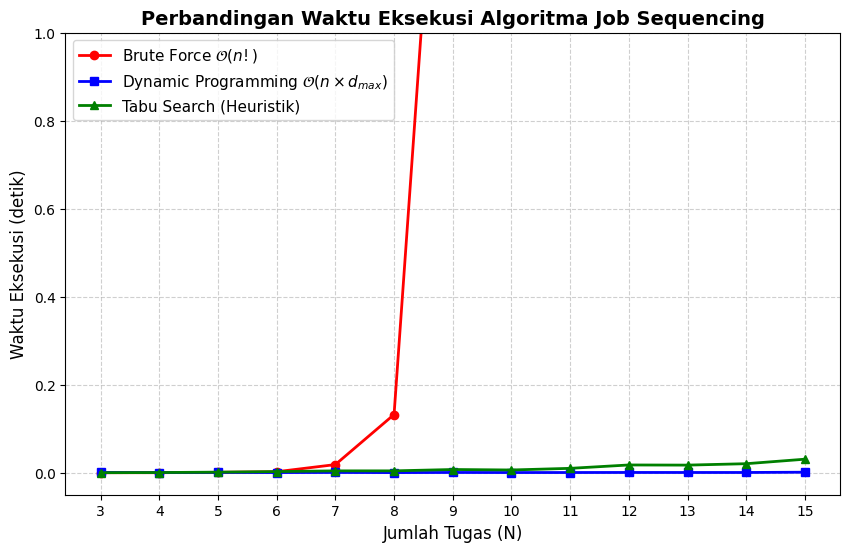

In [ ]:
import matplotlib.pyplot as plt
import time

n_values = list(range(3, 16)) 
waktu_bf = []
waktu_dp = []
waktu_ts = []

print("Memulai pengujian waktu eksekusi untuk grafik. Mohon tunggu sebentar...")

for n in n_values:
    subset = daftar_tugas[:n]
    
    # 1. Evaluasi Waktu Brute Force
    mulai = time.perf_counter()
    brute_force_sequencing_with_timeout(subset, batas_waktu_detik=2)
    selesai = time.perf_counter()
    
    waktu_bf.append(selesai - mulai)
    
    mulai = time.perf_counter()
    dynamic_programming_sequencing_with_timeout(subset, batas_waktu_detik=2)
    selesai = time.perf_counter()
    waktu_dp.append(selesai - mulai)
    
    mulai = time.perf_counter()
    tabu_search_sequencing_with_timeout(subset, batas_waktu_detik=2, max_iter=50, ukuran_tabu=5)
    selesai = time.perf_counter()
    waktu_ts.append(selesai - mulai)

# MEMBUAT GRAFIK 
plt.figure(figsize=(10, 6))

# Plotting garis untuk masing-masing algoritma
plt.plot(n_values, waktu_bf, marker='o', color='red', linewidth=2, label='Brute Force $\mathcal{O}(n!)$')
plt.plot(n_values, waktu_dp, marker='s', color='blue', linewidth=2, label='Dynamic Programming $\mathcal{O}(n \\times d_{max})$')
plt.plot(n_values, waktu_ts, marker='^', color='green', linewidth=2, label='Tabu Search (Heuristik)')

# Pengaturan tata letak dan estetika grafik
plt.title('Perbandingan Waktu Eksekusi Algoritma Job Sequencing', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Tugas (N)', fontsize=12)
plt.ylabel('Waktu Eksekusi (detik)', fontsize=12)

# INI TRIK BUAT BRUTE FORCE KARENA KOMPUTER SAYA GAKUAT KALO SAMPE > 9 DATA
plt.ylim(-0.05, 1.0) 
plt.xticks(n_values)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)

# Menyimpan grafik jadi png
plt.savefig('grafik_perbandingan_waktu.png', dpi=300, bbox_inches='tight')

print("Pengujian selesai! Grafik berhasil disimpan sebagai 'grafik_perbandingan_waktu.png'.")
# Menampilkan grafik
plt.show()

In [ ]:
# 1. URUTAN TUGAS KULIAH DISUSUN PAKAI ALGORITMA BRUTE FORCE (N=9, YAK KARENA GAKUAT KALO 15 KELAMAAN)
subset_bf = daftar_tugas[:9]
profit_bf, urutan_bf, _ = brute_force_sequencing_with_timeout(subset_bf, batas_waktu_detik=2)

print("=== URUTAN TUGAS BRUTE FORCE (N=7) ===")
print(f"Total Profit Maksimal: {profit_bf}")
print("Urutan Pengerjaan:")
for i, tugas in enumerate(urutan_bf):
    print(f"  {i+1}. {tugas['ID_Tugas']} - {tugas['Nama_Tugas']} "
          f"(Durasi: {tugas['Durasi_Pengerjaan_Jam']}j, Deadline: {tugas['Deadline_Jam']}j, Bobot: {tugas['Bobot_Nilai']})")
print("\n" + "-"*60 + "\n")


# 2. URUTAN TUGAS KULIAH DISUSUN PAKAI ALGORITMA DYNAMIC PROGRAMMING (N=15)
subset_full = daftar_tugas[:15]
profit_dp, urutan_dp, _ = dynamic_programming_sequencing_with_timeout(subset_full, batas_waktu_detik=2)

print("=== URUTAN TUGAS DYNAMIC PROGRAMMING (N=15) ===")
print(f"Total Profit Maksimal: {profit_dp}")
print("Urutan Pengerjaan:")
for i, tugas in enumerate(urutan_dp):
    print(f"  {i+1}. {tugas['ID_Tugas']} - {tugas['Nama_Tugas']} "
          f"(Durasi: {tugas['Durasi_Pengerjaan_Jam']}j, Deadline: {tugas['Deadline_Jam']}j, Bobot: {tugas['Bobot_Nilai']})")
print("\n" + "-"*60 + "\n")


# 3. URUTAN TUGAS KULIAH DISUSUN PAKAI ALGORITMA TABU SEARCH (N=15)
profit_ts, urutan_ts, _ = tabu_search_sequencing_with_timeout(subset_full, batas_waktu_detik=2, max_iter=50, ukuran_tabu=5)

print("=== URUTAN TUGAS TABU SEARCH (N=15) ===")
print(f"Total Profit Maksimal: {profit_ts}")
print("Urutan Pengerjaan:")
for i, tugas in enumerate(urutan_ts):
    print(f"  {i+1}. {tugas['ID_Tugas']} - {tugas['Nama_Tugas']} "
          f"(Durasi: {tugas['Durasi_Pengerjaan_Jam']}j, Deadline: {tugas['Deadline_Jam']}j, Bobot: {tugas['Bobot_Nilai']})")

=== URUTAN TUGAS BRUTE FORCE (N=7) ===
Total Profit Maksimal: 175
Urutan Pengerjaan:
  1. T1 - Proyek Makalah ASA (Durasi: 8j, Deadline: 48j, Bobot: 30)
  2. T5 - Tugas Teori GTI (Durasi: 2j, Deadline: 24j, Bobot: 10)
  3. T6 - Kuis Kecerdasan Buatan (Durasi: 2j, Deadline: 12j, Bobot: 20)
  4. T2 - Praktikum Jarkom (Durasi: 3j, Deadline: 24j, Bobot: 10)
  5. T4 - Laporan Praktikum Basdat (Durasi: 4j, Deadline: 48j, Bobot: 15)
  6. T9 - Laporan Sistem Operasi (Durasi: 4j, Deadline: 24j, Bobot: 15)
  7. T3 - Tugas Besar PBO (Durasi: 10j, Deadline: 72j, Bobot: 40)
  8. T7 - Modul Praktikum RPL (Durasi: 5j, Deadline: 72j, Bobot: 25)
  9. T8 - Tugas Matriks Ruang Vektor (Durasi: 3j, Deadline: 48j, Bobot: 10)

------------------------------------------------------------

=== URUTAN TUGAS DYNAMIC PROGRAMMING (N=15) ===
Total Profit Maksimal: 285
Urutan Pengerjaan:
  1. T6 - Kuis Kecerdasan Buatan (Durasi: 2j, Deadline: 12j, Bobot: 20)
  2. T2 - Praktikum Jarkom (Durasi: 3j, Deadline: 24j, Bob